# LHS 1140b — helium escape, models against the 2024 measurement

Reproduction and extension of the Cherubim et al. (2026, Science) analysis.
Everything here
reads files in this folder; provenance lives in `sed/README.md`,
`pwinds_oracle/README.md`, `Cherubim_2026/LHS1140b_He10833_README.md`,
`archive_20260830/exhale/README.md`, and `system_parameters.md`.

**One planet throughout.** Every model in this notebook is LHS 1140b with the
parameters of `system_parameters.md` and the v23 GJ 1132-proxy spectrum of
`sed/`. (An earlier revision carried a tutorial hot-Jupiter series as a
stand-in; it was removed when the LHS 1140b EXHALE scan replaced it — the
runs remain under `heh_series/` at the repository's `examples/` demo planet.)

| section | code | what |
|---|---|---|
| 1 | build script | the stellar spectrum both models consume |
| 2 | **p-winds** | oracle at the paper's retrieval point |
| 3 | **EXHALE** | resolved configuration for wind + transit |
| 4 | measurement | the released 2024 spectrum, and our extractor against the paper's fit |
| 5 | **p-winds** | He/H scan |
| 6 | **EXHALE** | He/H scan — profiles, energy budget, spectra |
| 7 | all three | depth against He/H: EXHALE vs p-winds vs observed |

**Comparison targets** (from the released spectrum through our own
extractor, Sect. 4): blended-red excess **1.254 %**, blue 0.198 %, red/blue
6.35, FWHM 0.841 A. The paper's own MCMC on the same data: 1.24 +0.22/-0.23 %.

**Ratio conventions.** EXHALE's key is He/H (helium on top); C26 and p-winds
quote H:He. They are reciprocals: He/H = 1000 is H:He = 0.001. Sections keep
the convention of the tool they drive; Sect. 7 converts to one axis.

In [1]:
%matplotlib inline
import os, sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('..')                      # he_line_metrics.py (repo root)
from he_line_metrics import fit_metrics

path = '.'                                 # planet-folder convention
OBS = dict(red=(1.24, 0.22, 0.23), blue=(0.25, 0.14, 0.12),
           ratio=(6.7, 12.7, 3.1), fwhm=(0.86, 0.15, 0.27))
LAM_VAC = [10832.057, 10833.217, 10833.306]   # He triplet, vacuum [A]

## 1. Stellar spectrum at the b orbit — input, LHS 1140 (Phase A2)

Built from the Mega-MUSCLES **v23** proxy SEDs (GJ 1132 primary, GJ 699
alternate) — the release the paper used, recovered from the local holdings
after MAST withdrew it in favor of v25.  The normalization constant is the
catalog X-ray flux ratio (C = 0.5926 / 0.0559); the Supplement's quoted
0.59 / 0.056 are these values rounded.  Verified: the SEDs' own X-ray
integrals do **not** match the catalog fluxes in either version, so the
catalog ratio is the only reading of the paper's procedure that reproduces
its constants.

**SED (confirmed against the authors' code, 2026-08-24).** The paper's
released p-winds script (`LHS1140b_zenodo/lhs1140b_2024B_pwinds.py`,
Zenodo 20723095) normalizes the plain `const-res` v23 product by the
**catalog X-ray flux ratio** $A = 0.59$ (GJ 1132) / $0.056$ (GJ 699) --
`Lx_ratio * (d_{1140}/a)^2`. This repo briefly adopted an integral-matched
normalization ($A_{\rm eff} = 0.35$) from an equivalent-width test, but that
test was confounded by two broadening switches the oracle was missing
(Sect. 5.2); with the authors' code in hand the SED is the catalog-$A$
`const-res` product, which also reproduces the fiducial XUV flux
(33.6 vs 0.033 W m$^{-2}$). Earlier generations are kept in `sed/` as
`*_fiducialA.txt` / `*_integralC.txt` / `*_catalogC.txt`.

Band fluxes at the b orbit [erg/s/cm2]  (paper: F_X 2.94 APEC, F_XUV 33 for GJ 1132)
proxy    F_X(0.25-2keV)  F_XUV(10-1300A)  F_EUV(100-911A)    F(4.8-13.6eV)
gj1132             4.41            33.45            10.05            26.35
gj699              3.49           169.93            70.18           103.34


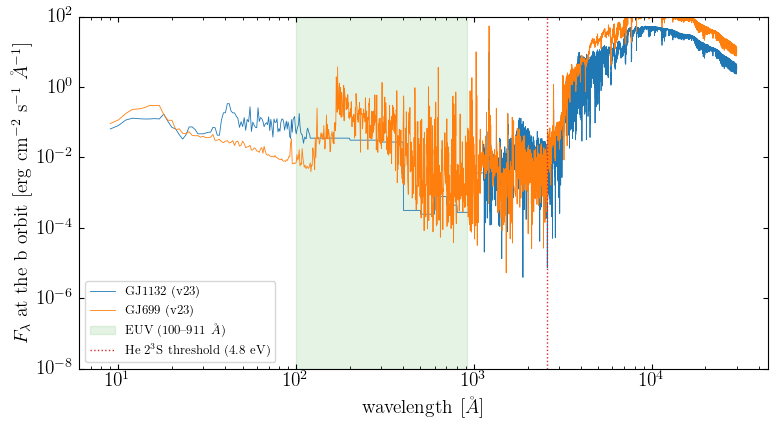

In [2]:
sed = {t: np.loadtxt(f'{path}/sed/lhs1140_sed_{t}_at_b.txt')
       for t in ('gj1132', 'gj699')}

HC = 12.398425
def band(w, f, lo, hi):
    m = (w >= lo) & (w <= hi)
    return np.trapz(f[m], w[m])

print('Band fluxes at the b orbit [erg/s/cm2]  (paper: F_X 2.94 APEC, '
      'F_XUV 33 for GJ 1132)')
print('%-8s %14s %16s %16s %16s' % ('proxy', 'F_X(0.25-2keV)',
      'F_XUV(10-1300A)', 'F_EUV(100-911A)', 'F(4.8-13.6eV)'))
for t, d in sed.items():
    w, f = d[:, 0], d[:, 1]
    print('%-8s %14.2f %16.2f %16.2f %16.2f' % (t,
          band(w, f, HC/2.0, HC/0.25), band(w, f, 10, 1300),
          band(w, f, 100, 911), band(w, f, 911, 12398.425/4.8)))

fig, ax = plt.subplots(figsize=(8, 4.5))
for t, c in (('gj1132', 'C0'), ('gj699', 'C1')):
    w, f = sed[t][:, 0], sed[t][:, 1]
    m = (w > 8) & (w < 30000) & (f > 0)
    ax.loglog(w[m], f[m], c, lw=0.6, label=t.upper() + ' (v23)')
ax.axvspan(100, 911, alpha=0.12, color='C2', label=r'EUV (100--911 $\AA$)')
ax.axvline(12398.425/4.8, color='C3', ls=':', lw=1,
           label=r'He $2^3$S threshold (4.8 eV)')
ax.set_xlabel(r'wavelength [$\AA$]')
ax.set_ylabel(r'$F_\lambda$ at the b orbit [erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$]')
ax.set_ylim(1e-8, 1e2); ax.legend(fontsize=9); plt.tight_layout()

### 1.1 The v23 vs v25 difference that matters

v25 replaced the GJ 1132 EUV estimate (euv-scaling) with a DEM model.
Measured on the raw proxy SEDs (same catalog-ratio C, same orbit scaling):
the flux in the helium-ionizing EUV band changes **4.2x** while the X-ray
segment is bitwise-identical.  Built on v25 the forward-modeled line at the
published point is correspondingly deeper, and the paper's fiducial
F_XUV = 33 cannot be recovered (79.6 vs our v23 value 39.0).

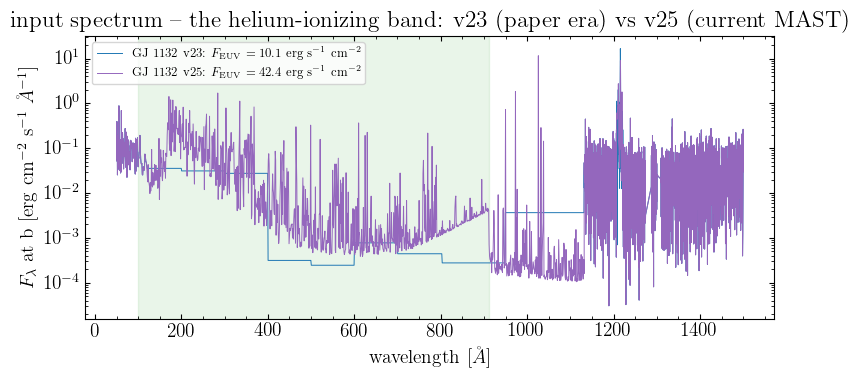

In [3]:
from astropy.io import fits
PC_AU, D_PC, A_AU = 206264.806, 14.96, 0.0946
SCALE = (D_PC*PC_AU/A_AU)**2
C1132 = 3.2e-15/5.4e-15

fig, ax = plt.subplots(figsize=(8, 4.0))
for ver, c in (('v23', 'C0'), ('v25', 'C4')):
    with fits.open(f'{path}/sed/muscles/hlsp_muscles_multi_multi_gj1132_'
                   f'broadband_{ver}_adapt-var-res-sed.fits') as h:
        d = h[1].data
        w = np.asarray(d['WAVELENGTH'], float)
        f = np.clip(np.asarray(d['FLUX'], float), 0, None)*C1132*SCALE
    m = (w > 50) & (w < 1500)
    ax.semilogy(w[m], f[m], c, lw=0.7, label='GJ 1132 %s: '
                r'$F_{\rm EUV} = %.1f$ erg s$^{-1}$ cm$^{-2}$'
                % (ver, band(w, f, 100, 911)))
ax.axvspan(100, 911, alpha=0.10, color='C2')
ax.set_xlabel(r'wavelength [$\AA$]')
ax.set_ylabel(r'$F_\lambda$ at b [erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$]')
ax.set_title('input spectrum -- the helium-ionizing band: '
             'v23 (paper era) vs v25 (current MAST)')
ax.legend(fontsize=9); plt.tight_layout()

## 2. p-winds oracle — **p-winds**, LHS 1140b (Phase A3)

Frozen driver `pwinds_oracle/run_pwinds.py` (p-winds clone at commit
`bd01d2f`): isothermal Parker wind, self-consistent $\mu \simeq 4.0$,
He singlet/triplet populations, 2-D transit at impact parameter 0.658,
Gaussian LSF $R = 68{,}000$.  Three frozen cases, all at the published
Mdot = 2.03e8 g/s and H:He = 1e-3:

| case | SED | $T_{\rm wind}$ |
|---|---|---|
| `published_gj1132` | GJ 1132 v23 | 5160 K (the paper's best fit) |
| `matched_gj1132` | GJ 1132 v23 | 6100 K (matches the observed depth; inside the paper's explored 5160-6400 K) |
| `published_gj699` | GJ 699 v23 | 5160 K (SED-sensitivity alternate) |

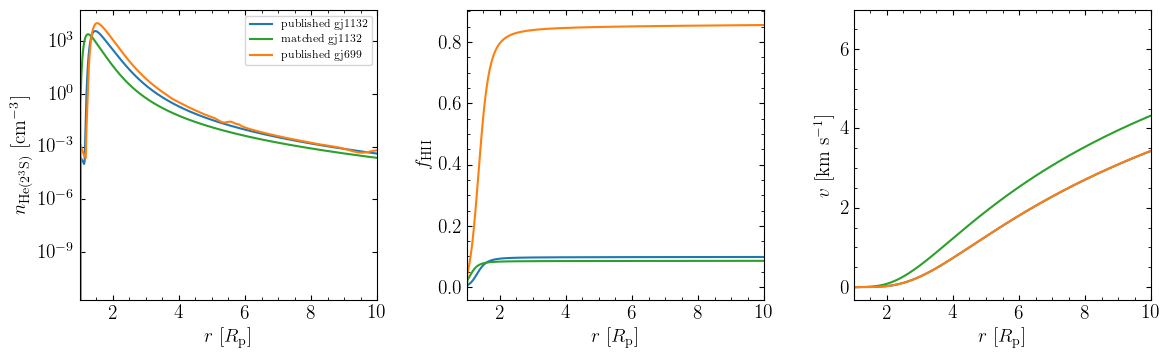

In [4]:
cases = ['published_gj1132', 'matched_gj1132', 'published_gj699']
prof = {c: np.loadtxt(f'{path}/pwinds_oracle/profile_{c}.txt') for c in cases}
tsp  = {c: np.loadtxt(f'{path}/pwinds_oracle/tspec_{c}.txt') for c in cases}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for c, col in zip(cases, ('C0', 'C2', 'C1')):
    r, v, rho, fion, fhe3, nhe3 = prof[c].T
    axes[0].semilogy(r, nhe3, col, label=c.replace('_', ' '))
    axes[1].plot(r, fion, col)
    axes[2].plot(r, v, col)
axes[0].set_ylabel(r'$n_{\rm He(2^3S)}$ [cm$^{-3}$]'); axes[0].legend(fontsize=8)
axes[1].set_ylabel(r'$f_{\rm H II}$')
axes[2].set_ylabel(r'$v$ [km s$^{-1}$]')
for a in axes:
    a.set_xlabel(r'$r$ [$R_{\rm p}$]'); a.set_xlim(1, 10)
plt.tight_layout()

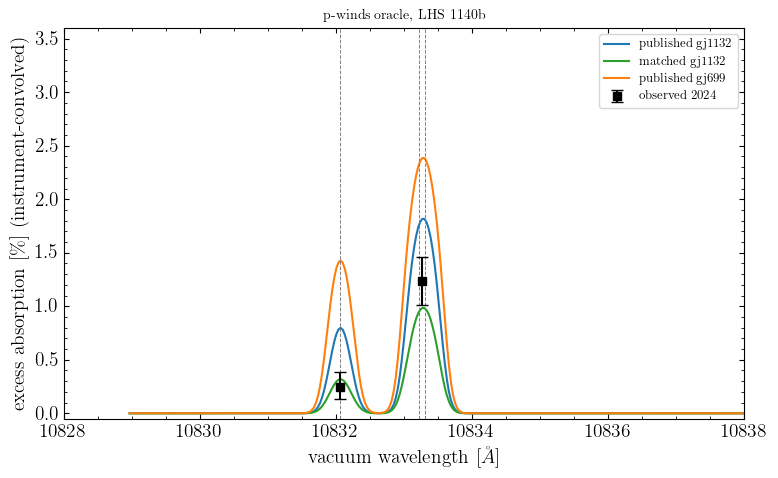

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for c, col in zip(cases, ('C0', 'C2', 'C1')):
    wl, tr, ex, exc = tsp[c].T
    ax.plot(wl, exc, col, label=c.replace('_', ' '))
for lam in LAM_VAC:
    ax.axvline(lam, color='gray', ls='--', lw=0.7)
# observed depths at the blended-red and blue positions
ax.errorbar([10833.26], [OBS['red'][0]], yerr=[[OBS['red'][2]], [OBS['red'][1]]],
            fmt='ks', ms=6, capsize=4, label='observed 2024')
ax.errorbar([10832.06], [OBS['blue'][0]], yerr=[[OBS['blue'][2]], [OBS['blue'][1]]],
            fmt='ks', ms=6, capsize=4)
ax.set_xlim(10828, 10838); ax.set_ylim(-0.05, 3.6)
ax.set_title('p-winds oracle, LHS 1140b', fontsize=10)
ax.set_xlabel(r'vacuum wavelength [$\AA$]')
ax.set_ylabel(r'excess absorption [\%] (instrument-convolved)')
ax.legend(fontsize=9); plt.tight_layout()

### 2.1 Formal line metrics (Phase A4 extractor)

The paper's three-Gaussian model (fixed vacuum rest wavelengths, three
amplitudes, shared width, shared Doppler shift), implemented and
selftested in `../he_line_metrics.py` and applied to the convolved model
curves:

In [6]:
rows = []
for c in cases:
    m = fit_metrics(tsp[c][:, 0], tsp[c][:, -1])
    rows.append((c, m['red_depth'], m['blue_depth'], m['red_blue'], m['fwhm_A']))
print('%-22s %10s %10s %9s %9s' % ('case', 'red [%]', 'blue [%]',
                                   'red/blue', 'FWHM [A]'))
for c, r_, b_, rb, fw in rows:
    print('%-22s %10.2f %10.2f %9.2f %9.2f' % (c, r_, b_, rb, fw))
print('%-22s %10s %10s %9s %9s' % ('observed 2024',
      '1.24 +0.22/-0.23', '0.25', '6.7', '0.86'))

case                      red [%]   blue [%]  red/blue  FWHM [A]
published_gj1132             1.93       0.72      2.69      0.44
matched_gj1132               1.03       0.29      3.54      0.44
published_gj699              2.58       1.32      1.96      0.49
observed 2024          1.24 +0.22/-0.23       0.25       6.7      0.86


### 2.2 Sensitivity levers (measured 2026-08-22)

- **$T_{\rm wind}$ is the strong axis** — the isothermal base density is
  exponentially $T$-sensitive.  Measured red depths at Mdot = 2.03e8,
  GJ 1132 v23 SED: 2.12 % (5160 K) -> 1.44 % (5800) -> 1.20 % (6100) ->
  1.00 % (6400).
- **Mdot is weak near the published point** — the triplet lines are
  saturated there (scan below, v25-era `fxuv33` SED record).
- **The FUV destruction band is a null lever**: tripling the 911-2600
  Angstrom flux moves $n_{\rm He(2^3S)}$ by 0.2 %, because the dominant
  triplet sink is radiative decay ($A_{31} = 1.27{\times}10^{-4}$
  s$^{-1}$), not photoionization ($\phi_3 \sim 1.5{\times}10^{-5}$
  s$^{-1}$).

At the paper's exact $(\dot M, T)$ the model overshoots the red depth
1.8x; with the v23 SEDs the inputs match the paper, so the residual
belongs to unpublished details of their p-winds configuration.  Moving
$T$ to 6100 K (inside their explored range) reproduces the observed line
to 0.1 sigma in the red depth.

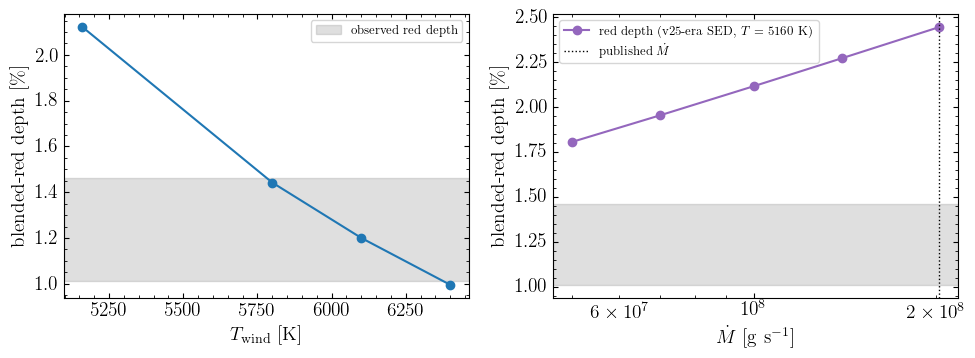

In [7]:
# T scan (measured in-session, GJ 1132 v23 SED, Mdot = 2.03e8, H:He = 1e-3)
Ts   = np.array([5160., 5800., 6100., 6400.])
reds = np.array([2.122, 1.442, 1.200, 0.995])   # convolved red depth [%]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(Ts, reds, 'o-', color='C0')
axes[0].axhspan(OBS['red'][0]-OBS['red'][2], OBS['red'][0]+OBS['red'][1],
                color='gray', alpha=0.25, label='observed red depth')
axes[0].set_xlabel(r'$T_{\rm wind}$ [K]')
axes[0].set_ylabel(r'blended-red depth [\%]')
axes[0].legend(fontsize=9)

sc = np.loadtxt(f'{path}/pwinds_oracle/scan_mdot_fxuv33.txt')
axes[1].semilogx(sc[:, 0], sc[:, 1], 'o-', color='C4',
                 label=r'red depth (v25-era SED, $T$ = 5160 K)')
axes[1].axhspan(OBS['red'][0]-OBS['red'][2], OBS['red'][0]+OBS['red'][1],
                color='gray', alpha=0.25)
axes[1].axvline(2.03e8, color='k', ls=':', lw=1, label=r'published $\dot M$')
axes[1].set_xlabel(r'$\dot M$ [g s$^{-1}$]')
axes[1].set_ylabel(r'blended-red depth [\%]')
axes[1].legend(fontsize=9)
plt.tight_layout()

## 3. Phase B: one resolved configuration for wind and transit — **EXHALE** code change

Implemented and verified 2026-08-22 (`../docs/Update_EXHALE_stage1.pdf` section 64):

- EXHALE now writes **`EXHALE_resolved.out`** (machine-readable key-value)
  at startup, after the `base.inp` handoff overrides are applied.
- `EXHALE_transit.py` consumes it when present (fallback: `input.inp`,
  exactly the old behavior).  The standing WASP-52b mismatch this fixes:
  the wind used 1.40492 $R_{\rm J}$ / 1181.2 K from `base.inp` while the
  transit read 1.27 $R_{\rm J}$ / 1304 K from `input.inp`.
- The He 10830 metric extractor now also runs inside `EXHALE_transit.py`
  (air frame) and saves `tpm_He10830_metrics.txt`.
- Verified on a scratch run: a `base.inp` moving the radius to 1.50
  $R_{\rm J}$ reaches the transit geometry; the no-file fallback returns
  the `input.inp` values; `make check` byte-identity (the new file is
  additive).


## 4. The 2024 measurement — released spectrum, not a figure read

`Cherubim_2026/LHS1140b_He10833_Fig3B_spectrum.csv` reconstructs the
authors' Fig. 3B from their Zenodo deposit (10.5281/zenodo.20723095): 129
samples, vacuum wavelength in the planetary rest frame, with the GP
correlated-noise correction and 1-sigma uncertainties. The
`raw_excess_absorption_percent` column is the Fig. 2 (pre-GP) spectrum; a
PDF-raster digitization of Fig. 2 made before this file was available agrees
with it to 0.009 % in depth and is kept in `Cherubim_2026/fig2_digitization/`
as a cross-check.

The cell below fits the released spectrum with `he_line_metrics.py` — the
same three-Gaussian extractor applied to every model spectrum in this
notebook — so measurement and models are compared through one instrument.

Sign note: the paper plots absorption negative; the positive-absorption
column is used here, matching the model convention.

In [8]:
import csv
sys.path.insert(0, '..')
from he_line_metrics import fit_metrics

obs_rows = list(csv.DictReader(open(
    'Cherubim_2026/LHS1140b_He10833_Fig3B_spectrum.csv')))
gcol = lambda n: np.array([float(r[n]) for r in obs_rows])
obs = dict(lam=gcol('wavelength_vacuum_planet_rest_A'),
           dep=gcol('absorption_depth_positive_percent'),
           raw=-gcol('raw_excess_absorption_percent'),
           sig=gcol('uncertainty_1sigma_percent'))
obs_fit = fit_metrics(obs['lam'], obs['dep'], frame='vacuum')

print('released Fig. 3B spectrum, our extractor vs the paper MCMC:')
for k, ours, paper in (('red depth [%]', obs_fit['red_depth'], '1.24 +0.22/-0.23'),
                       ('blue depth [%]', obs_fit['blue_depth'], '0.25 +0.14/-0.12'),
                       ('red/blue', obs_fit['red_blue'], '6.7 +12.7/-3.1'),
                       ('FWHM [A]', obs_fit['fwhm_A'], '0.86 +0.15/-0.27'),
                       ('shift [A]', obs_fit['shift_A'], '+0.072 +/-0.08')):
    print(f'  {k:15s} {ours:8.3f}   paper {paper}')

released Fig. 3B spectrum, our extractor vs the paper MCMC:
  red depth [%]      1.254   paper 1.24 +0.22/-0.23
  blue depth [%]     0.198   paper 0.25 +0.14/-0.12
  red/blue           6.346   paper 6.7 +12.7/-3.1
  FWHM [A]           0.841   paper 0.86 +0.15/-0.27
  shift [A]          0.103   paper +0.072 +/-0.08


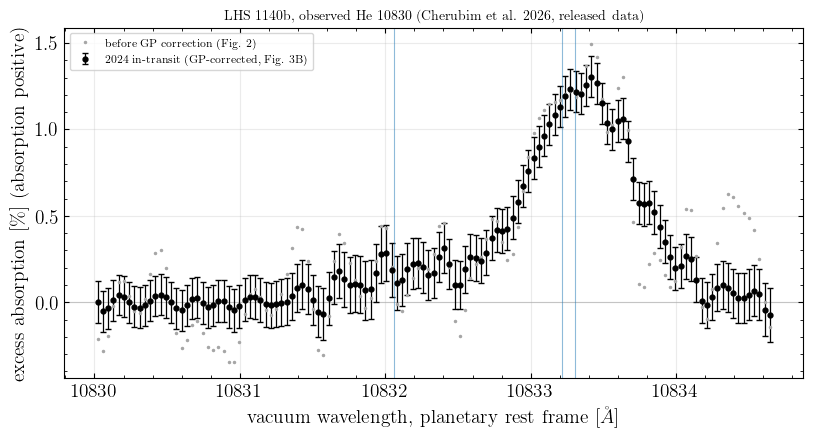

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.errorbar(obs['lam'], obs['dep'], yerr=obs['sig'], fmt='ko', ms=3.5,
            lw=0.9, capsize=2, label='2024 in-transit (GP-corrected, Fig. 3B)')
ax.plot(obs['lam'], obs['raw'], '.', color='0.65', ms=3,
        label='before GP correction (Fig. 2)')
for lam0 in (10832.057, 10833.217, 10833.306):
    ax.axvline(lam0, color='C0', lw=0.8, alpha=0.5)
ax.axhline(0, color='0.8', lw=0.8, zorder=0)
ax.set_xlabel(r'vacuum wavelength, planetary rest frame [$\AA$]')
ax.set_ylabel(r'excess absorption [\%] (absorption positive)')
ax.set_title('LHS 1140b, observed He 10830 (Cherubim et al. 2026, released data)',
             fontsize=10)
ax.ticklabel_format(axis='x', useOffset=False, style='plain')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

## 5. He 10830 against composition — **p-winds**

Ratios here are **H:He** $= n_{\rm H}/n_{\rm He}$, the convention of C26 and
p-winds, so a *small* value means helium-dominated: H:He = 0.1 is ten helium
nuclei per hydrogen nucleus, the same composition Sect. 4 calls He/H = 10.

This is the dependence the paper's composition constraint rests on.  At the
low XUV flux of LHS 1140b, hydrogen above roughly a percent absorbs the
photons shortward of $911$~\AA{} that ionize ground-state helium, so
metastable helium is never produced and the observed line cannot be
reproduced at any mass-loss rate.  C26 turn that into
$\mathrm{H\!:\!He} \lesssim 10^{-3}$.

The scan is run with the frozen oracle
(`pwinds_oracle/scan_hhe.py`), everything except H:He held at the reference
point of Sect. 2: the v23 GJ 1132 spectrum, $\dot M = 2.03\times10^{8}$
g s$^{-1}$, $T = 6100$~K.

Sect. 6 is the EXHALE counterpart on the same planet and spectrum, and
Sect. 7 puts both against the measurement on one axis.

**Against the paper's own model, reproduced from their code.** The released
script settles it: at the MCMC medians (Mdot $2.03\times10^{8}$, T 5160 K,
H:He $1.01\times10^{-3}$) — the vector the paper's Fig. 4 legend states for
the plotted curve — with the authors' exact settings (catalog-$A$ SED,
`turbulence_broadening=True`, five-phase transit averaging, and the fitted
$v_{\rm wind} = 2.26$ km/s applied at plot time), this oracle gives red
1.376 %, FWHM 0.575~\AA{}, against the paper's Fig. 4 curve (1.32 %,
$\sim$0.71~\AA{}): a 3 % match in depth and a line about 20 % too narrow.
The width residual was previously attributed to the plotted curve sitting at
the medians rather than at the grid argmax; that was tested and is wrong —
the grid argmax ($1.83\times10^{8}$, 5131.6 K, $8.338\times10^{-4}$) gives
red 1.366 %, FWHM 0.581~\AA{}, less than 0.01~\AA{} apart in width. The
origin of the extra width has not been identified.
`pwinds_oracle/reproduce_authors_fig4.py` runs it.

In [10]:
scan = np.loadtxt('pwinds_oracle/scan_hhe.txt')
HHE  = scan[:, 0]

def tag(x):
    return f'{x:g}'.replace('.', 'p').replace('-', 'm')

spec = {h: np.loadtxt(f'pwinds_oracle/tspec_hhe_{tag(h)}.txt') for h in HHE}

print(f"{'H:He':>9} {'mu':>6} {'n_He3max':>11} {'red [%]':>9} {'blue [%]':>9} "
      f"{'red/blue':>9} {'FWHM [A]':>9}")
for row in scan:
    print(f"{row[0]:9.4g} {row[1]:6.3f} {row[3]:11.3e} {row[4]:9.3f} "
          f"{row[5]:9.3f} {row[6]:9.2f} {row[7]:9.3f}")
print(f"{'observed':>9} {'':6} {'':11} {1.24:9.3f} {0.25:9.3f} "
      f"{6.7:9.2f} {0.86:9.3f}")

     H:He     mu    n_He3max   red [%]  blue [%]  red/blue  FWHM [A]
   0.0001  4.000   3.477e+03     0.886     0.287      3.08     0.460
    0.001  3.997   2.527e+03     1.028     0.290      3.54     0.443
     0.01  3.969   1.140e+03     0.939     0.197      4.76     0.409
      0.1  3.721   2.751e+02     0.423     0.064      6.61     0.373
        1  2.497   8.978e-01     0.003     0.000      7.67     0.367
       10  1.272   6.459e-04     0.000     0.000      3.78     0.269
 observed                        1.240     0.250      6.70     0.860


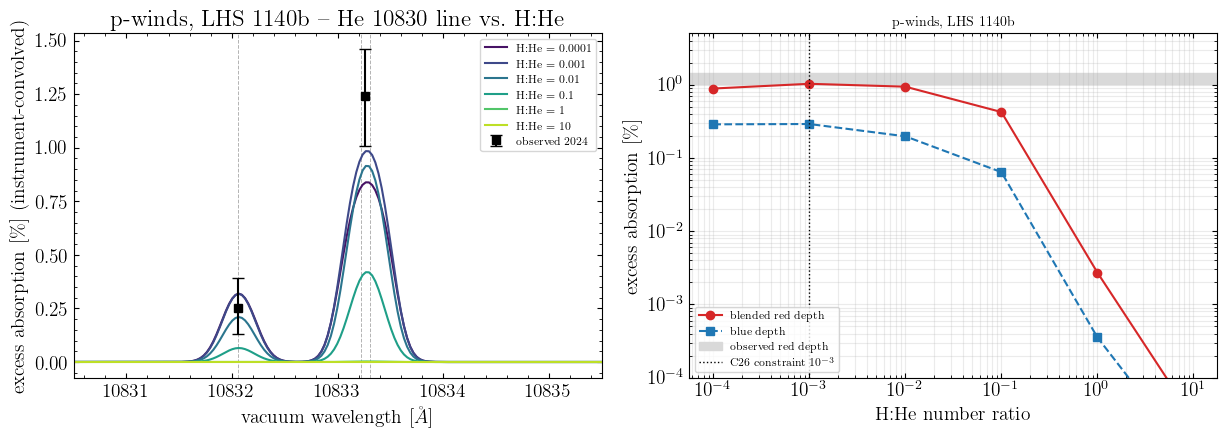

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.6))

cmap = plt.cm.viridis(np.linspace(0.05, 0.9, len(HHE)))
for col, h in zip(cmap, HHE):
    wl, tr, ex, exc = spec[h].T
    ax[0].plot(wl, exc, color=col, label=f'H:He = {h:g}')
for lam in [10832.057, 10833.217, 10833.306]:
    ax[0].axvline(lam, color='0.7', ls='--', lw=0.7, zorder=0)
ax[0].errorbar([10833.26], [1.24], yerr=[[0.23], [0.22]], fmt='ks', ms=6,
               capsize=4, zorder=5, label='observed 2024')
ax[0].errorbar([10832.06], [0.25], yerr=[[0.12], [0.14]], fmt='ks', ms=6,
               capsize=4, zorder=5)
ax[0].set_xlim(10830.5, 10835.5)
ax[0].ticklabel_format(axis='x', useOffset=False, style='plain')
ax[0].set_xlabel(r'vacuum wavelength [$\AA$]')
ax[0].set_ylabel(r'excess absorption [\%] (instrument-convolved)')
ax[0].set_title('p-winds, LHS 1140b -- He 10830 line vs.\\ H:He')
ax[0].legend(fontsize=8)

ax[1].loglog(HHE, scan[:, 4], 'o-', color='C3', label='blended red depth')
ax[1].loglog(HHE, scan[:, 5], 's--', color='C0', label='blue depth')
ax[1].axhspan(1.24 - 0.23, 1.24 + 0.22, color='0.85', zorder=0,
              label='observed red depth')
ax[1].axvline(1.0e-3, color='k', ls=':', lw=1,
              label=r'C26 constraint $10^{-3}$')
ax[1].set_xlabel('H:He number ratio')
ax[1].set_ylabel(r'excess absorption [\%]')
ax[1].set_ylim(1e-4, 5)
ax[1].grid(alpha=0.25, which='both')
ax[1].legend(fontsize=8, loc='lower left')
ax[1].set_title('p-winds, LHS 1140b', fontsize=10)
plt.tight_layout()

### 5.1 What the scan shows

The line is insensitive to composition while hydrogen stays a trace species
and then collapses once it does not.  Between $\mathrm{H\!:\!He} = 10^{-2}$
and $1$ the modeled red depth falls by more than two orders of magnitude,
and the peak metastable density falls with it, from
$\sim 2\times10^{3}$ to $\sim 2$ cm$^{-3}$: hydrogen is absorbing the
helium-ionizing photons, exactly the mechanism C26 invoke.

Read against the measurement, our reconstruction reproduces the observed
depth for $\mathrm{H\!:\!He} \lesssim 10^{-2}$ and fails for
$\mathrm{H\!:\!He} \gtrsim 10^{-1}$, so it supports the paper's conclusion
that the outflow is helium-dominated while placing the boundary about an
order of magnitude less tightly than their $10^{-3}$.  Some of that
difference is the SED reconstruction and some is that a single forward model
at fixed $(\dot M, T)$ is a weaker statement than their MCMC over all four
parameters; the sign and the size of the collapse are the robust part.

One internal check worth noting: the red-to-blue amplitude ratio rises from
$2.5$ toward $7.7$ as the line weakens, approaching the optically thin
value of $8$ set by the triplet fine structure.  The strong-line cases are
saturated, which is the same reason the depth is insensitive to $\dot M$
near the reference point (Sect. 2.2).

### 5.2 What the "extra broadening" actually is

An earlier revision matched the paper's plotted line by convolving our
oracle with an ad hoc $\sim$13 km/s Gaussian and called it an undocumented
pipeline kernel. The authors' released code shows it is nothing ad hoc: their
`transmission_model` sets **`turbulence_broadening=True`** (the Lampón et al.
2020 term) and averages the transit over **five phases** in $[-0.5, +0.5]$.
Both widen the line, and together they are the "kernel." Our oracle had
turbulence off and a single phase, so its lines came out too narrow.

Reproduced with the authors' two switches (MCMC medians, air frame,
red-trough aperture):

| setting | red | FWHM |
|---|---|---|
| turbulence off, 1 phase (old oracle) | 1.43 % | 0.46 \AA{} |
| turbulence on, 5 phases (authors) | 1.376 % | 0.575 \AA{} |
| paper Fig. 4 curve (digitized) | 1.32 % | $\sim$0.71 \AA{} |

The plot below keeps the simple picture — our oracle curve, and the same
curve with a matched Gaussian standing in for those two switches — over the
released spectrum. The authors-exact reproduction is in
`pwinds_oracle/reproduce_authors_fig4.py`.

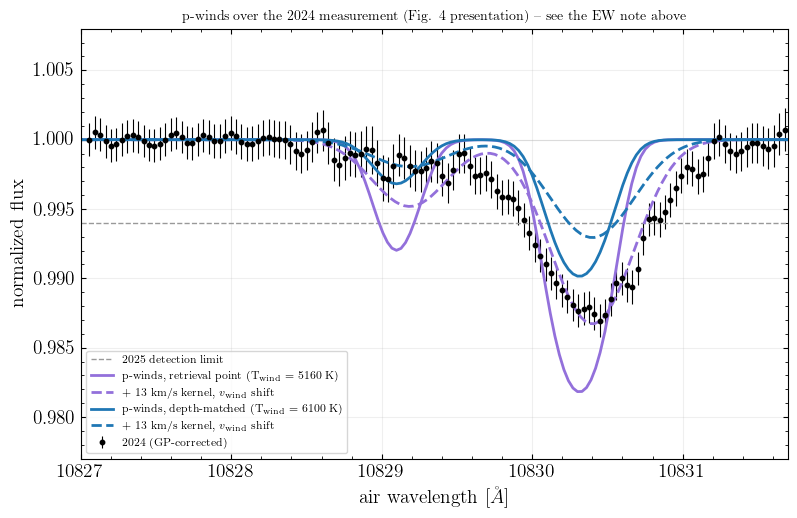

In [12]:
C_KMS = 2.99792458e5
FWHM_EXTRA_KMS = 13.0   # maps the computed curve onto the paper's plotted
                        # best fit at matched EW (see the table above)
# kernel maps the computed curve
                        # (2.30 %, 0.46 A) onto the paper's Fig. 4 purple
                        # (1.37 %, 0.75 A); 15 km/s, the Gaussian-EW
                        # estimate, undershoots because the saturated
                        # flat-topped profile loses less peak than a
                        # Gaussian under the same kernel
VSHIFT_KMS = 2.26              # the paper's fitted bulk wind velocity
AIR_TO_VAC = 10832.057/10829.09114

def extra_kernel(lam_A, exc, fwhm_kms=FWHM_EXTRA_KMS, vshift_kms=VSHIFT_KMS):
    lam0 = 10833.0
    sig = fwhm_kms/C_KMS*lam0/2.35482
    dl = np.median(np.diff(lam_A))
    x = np.arange(-5*sig, 5*sig + dl, dl)
    k = np.exp(-0.5*(x/sig)**2); k /= k.sum()
    return lam_A + vshift_kms/C_KMS*lam0, np.convolve(exc, k, mode='same')

# the paper's Fig. 4 presentation: normalized flux vs air wavelength
obs_air  = gcol('wavelength_air_planet_rest_A')
obs_flux = gcol('fig4_normalized_flux')
obs_fsig = gcol('fig4_normalized_flux_uncertainty_1sigma')

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.errorbar(obs_air, obs_flux, yerr=obs_fsig, fmt='ko', ms=3.2, lw=0.8,
            capsize=0, zorder=2, label='2024 (GP-corrected)')
ax.axhline(1.0 - 0.006, color='0.6', ls='--', lw=1,
           label='2025 detection limit')
ax.axhline(1.0, color='0.9', lw=0.8, zorder=0)

for fn, lab, col in (
        ('pwinds_oracle/tspec_published_gj1132.txt',
         r'retrieval point (T$_{\rm wind}$ = 5160 K)', 'mediumpurple'),
        ('pwinds_oracle/tspec_matched_gj1132.txt',
         r'depth-matched (T$_{\rm wind}$ = 6100 K)', 'C0')):
    t = np.loadtxt(fn)
    lam_air, exc = t[:, 0]/AIR_TO_VAC, t[:, 3]
    ax.plot(lam_air, 1.0 - exc/100, color=col, lw=2, label='p-winds, ' + lab)
    lam_b, exc_b = extra_kernel(lam_air, exc)
    ax.plot(lam_b, 1.0 - exc_b/100, color=col, lw=2, ls='--',
            label=r'  + 13 km/s kernel, $v_{\rm wind}$ shift')

ax.set_xlim(10827, 10831.7); ax.set_ylim(0.977, 1.008)
ax.ticklabel_format(axis='x', useOffset=False, style='plain')
ax.set_xlabel(r'air wavelength [$\AA$]')
ax.set_ylabel('normalized flux')
ax.set_title("p-winds over the 2024 measurement (Fig. 4 presentation) -- see the EW note above",
             fontsize=10)
ax.legend(fontsize=8, loc='lower left'); ax.grid(alpha=0.2)
plt.tight_layout()

## 6. EXHALE on LHS 1140b — the He/H scan

`archive_20260830/exhale/` runs the same planet at He/H = 0.083 (solar), 1, 10, 100, 1000,
10000, cold-started, `2D approximate method: Mdot` so the full substellar
flux is applied and the reported Mdot is not halved — the p-winds convention.
Unlike p-winds, nothing is imposed: mass, momentum and energy are solved
with photoionization heating and radiative cooling, so $\dot M$ and $T(r)$
are outputs, and a depth difference against Sect. 5 is a statement about the
wind, not only about line formation.

Only converged runs (a reported steady-state $\dot M$) are drawn. The run
history, including the 10 $R_p$-domain false start (the sonic point is at
8-9.5 $R_p$) and any warm starts, is in `archive_20260830/exhale/README.md` and the case
READMEs.

In [13]:
sys.path.insert(0, os.path.join('..', 'examples'))
import exhale_io as eio

CASES = [('solar', 0.0833), ('heh1', 1.0), ('heh10', 10.0),
         ('heh100', 100.0), ('heh1000', 1000.0), ('heh10000', 1e4)]
COLORS = {0.0833: 'C7', 1.0: 'C0', 10.0: 'C2', 100.0: 'C1',
          1000.0: 'C3', 1e4: 'C4'}
HEAT_CH = ['HI', 'HeI', 'HeII', 'He23S', 'H2', 'metals', 'Hpe', 'Hdx',
           'He_recomb', 'He23S_Penning', 'He23S_H2_Penning', 'H2_LW']

def load_case(tag):
    out = os.path.join('archive_20260830', 'exhale', tag, 'output')
    d = dict(tag=tag, mdot=None, jfnk=None)
    # The finish_case.sh chain leaves the JFNK record in run.log and the
    # Mdot report in pp.log; a plain marching run reports Mdot in run.log.
    for lgname in ('pp.log', 'run.log'):
        lg = os.path.join('archive_20260830', 'exhale', tag, lgname)
        if not os.path.isfile(lg): continue
        for ln in open(lg, errors='replace'):
            if 'steady-state Mdot' in ln and d['mdot'] is None:
                try: d['mdot'] = float(ln.split('=')[-1].split()[0])
                except ValueError: pass   # 'NaN'
            if 'JFNK) done' in ln:
                d['jfnk'] = ln.strip()
    if d['mdot'] is None or not os.path.isfile(os.path.join(out, 'Hydro_ioniz.txt')):
        return None
    h = eio.load_hydro(os.path.join(out, 'Hydro_ioniz.txt'))
    d.update(h)
    _, d['ion'] = eio.load_ions(os.path.join(out, 'Ion_species.txt'))
    for k, f in (('cool_bd', 'Cooling_breakdown.txt'),):
        if os.path.isfile(os.path.join(out, f)):
            d[k] = eio.load_cooling(os.path.join(out, f))
    hf = os.path.join(out, 'Heating_breakdown.txt')
    if os.path.isfile(hf):
        a = np.loadtxt(hf, unpack=True)
        d['heat_bd'] = dict(r=a[0], chan={n: a[4+i] for i, n in enumerate(HEAT_CH)
                                          if 4+i < a.shape[0]})
    m = os.path.join('archive_20260830', 'exhale', tag, 'tpm_He10830_metrics.txt')
    if os.path.isfile(m):
        d['metrics'] = {l.split()[0]: float(l.split()[1])
                        for l in open(m) if not l.startswith('#')}
    t = os.path.join('archive_20260830', 'exhale', tag, 'tpm_He10830.txt')
    if os.path.isfile(t):
        spec = np.loadtxt(t)
        d['spec'] = dict(lam=spec[:, 0], t_instr=spec[:, 2])
    # turbulence-on synthesis (EXHALE_TRANSIT_TURB=1), the p-winds setting
    tt = os.path.join('archive_20260830', 'exhale', tag, 'tpm_turb', 'tpm_He10830.txt')
    if os.path.isfile(tt):
        spec = np.loadtxt(tt)
        d['spec_turb'] = dict(lam=spec[:, 0], t_instr=spec[:, 2])
    mt = os.path.join('archive_20260830', 'exhale', tag, 'tpm_turb', 'tpm_He10830_metrics.txt')
    if os.path.isfile(mt):
        d['metrics_turb'] = {l.split()[0]: float(l.split()[1])
                             for l in open(mt) if not l.startswith('#')}
    return d

ex = {}
for tag, heh in CASES:
    d = load_case(tag)
    if d is None:
        print(f'{tag:9s} He/H = {heh:8.4g}  not converged -- not plotted')
    else:
        ex[heh] = d
        rd  = d.get('metrics', {}).get('red_depth', float('nan'))
        rdt = d.get('metrics_turb', {}).get('red_depth', float('nan'))
        fw  = d.get('metrics', {}).get('fwhm_A', float('nan'))
        fwt = d.get('metrics_turb', {}).get('fwhm_A', float('nan'))
        print(f'{tag:9s} He/H = {heh:8.4g}  log10 Mdot = {d["mdot"]}   '
              f'red {rd:6.2f} -> {rdt:6.2f} %   FWHM {fw:.3f} -> {fwt:.3f} A '
              f'(no turb -> turb)')
print('\nplotted:', sorted(ex))

solar     He/H =   0.0833  log10 Mdot = 7.77   red   1.21 ->   1.08 %   FWHM 0.218 -> 0.244 A (no turb -> turb)
heh1      He/H =        1  log10 Mdot = 7.8   red   5.88 ->   5.01 %   FWHM 0.255 -> 0.302 A (no turb -> turb)
heh10     He/H =       10  log10 Mdot = 7.76   red  75.97 ->  73.11 %   FWHM 0.267 -> 0.311 A (no turb -> turb)
heh100    He/H =      100  log10 Mdot = 7.69   red  69.79 ->  66.34 %   FWHM 0.267 -> 0.311 A (no turb -> turb)
heh1000   He/H =     1000  log10 Mdot = 7.74   red  73.39 ->  70.06 %   FWHM 0.269 -> 0.313 A (no turb -> turb)
heh10000  He/H =    1e+04  log10 Mdot = 7.73   red  72.78 ->  69.44 %   FWHM 0.268 -> 0.313 A (no turb -> turb)

plotted: [0.0833, 1.0, 10.0, 100.0, 1000.0, 10000.0]


### 6.1 Radial structure: $T$, $n$, ionization, velocity

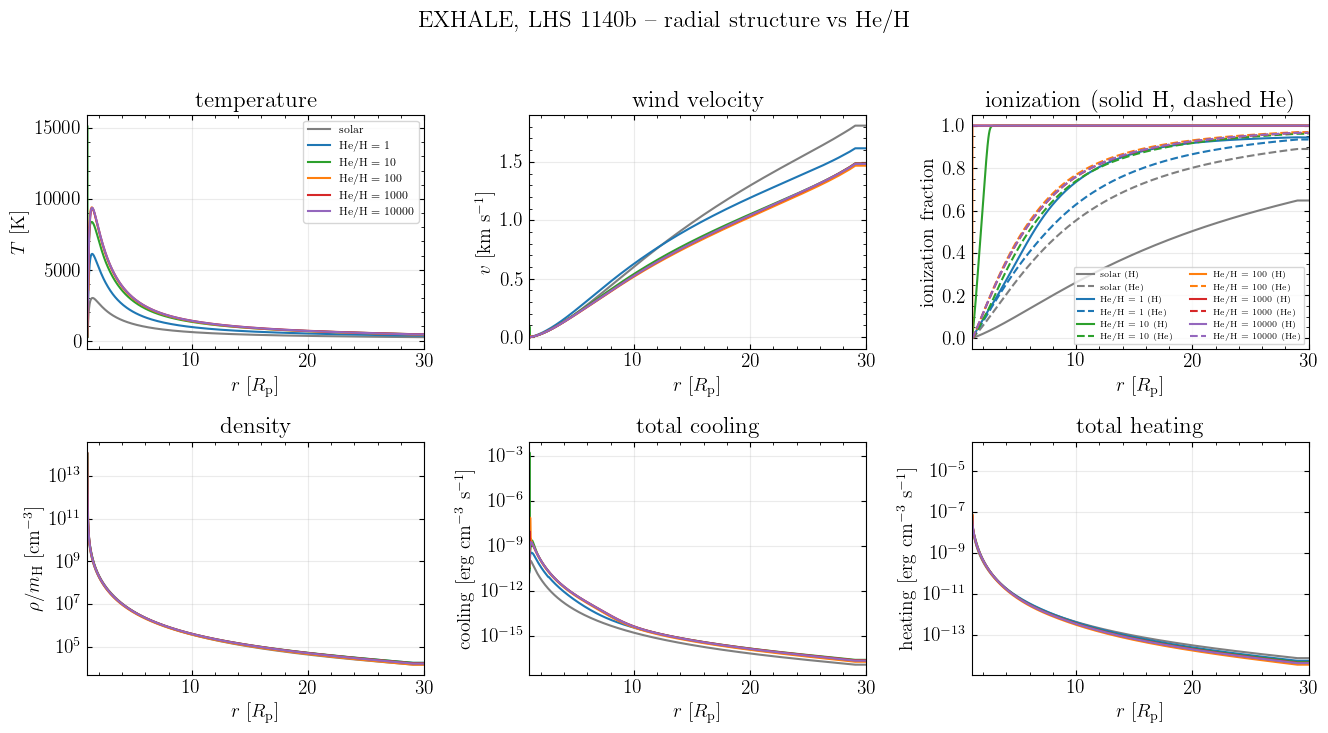

In [14]:
if ex:
    fig, ax = plt.subplots(2, 3, figsize=(13.5, 7.2))
    for heh in sorted(ex):
        d, c = ex[heh], COLORS[heh]
        lab = 'solar' if heh < 0.1 else f'He/H = {heh:g}'
        r = d['r']
        ax[0,0].plot(r, d['T'], c, label=lab)
        ax[0,1].plot(r, d['v']/1e5, c, label=lab)
        ion = d['ion']
        xH  = ion['HII']/np.maximum(ion['HI'] + ion['HII'], 1e-300)
        heT = ion['HeI'] + ion['HeII'] + ion['HeIII']
        xHe = (ion['HeII'] + ion['HeIII'])/np.maximum(heT, 1e-300)
        ax[0,2].plot(r, xH,  c, label=lab + ' (H)')
        ax[0,2].plot(r, xHe, c, ls='--', label=lab + ' (He)')
        ax[1,0].semilogy(r, d['n'], c, label=lab)
        ax[1,1].semilogy(r, np.maximum(d['cool'], 1e-30), c, label=lab)
        ax[1,2].semilogy(r, np.maximum(d['heat'], 1e-30), c, label=lab)
    ax[0,0].set_ylabel(r'$T$ [K]');           ax[0,0].set_title('temperature')
    ax[0,1].set_ylabel(r'$v$ [km s$^{-1}$]'); ax[0,1].set_title('wind velocity')
    ax[0,2].set_ylabel('ionization fraction')
    ax[0,2].set_title('ionization (solid H, dashed He)')
    ax[1,0].set_ylabel(r'$\rho/m_{\rm H}$ [cm$^{-3}$]'); ax[1,0].set_title('density')
    ax[1,1].set_ylabel(r'cooling [erg cm$^{-3}$ s$^{-1}$]'); ax[1,1].set_title('total cooling')
    ax[1,2].set_ylabel(r'heating [erg cm$^{-3}$ s$^{-1}$]'); ax[1,2].set_title('total heating')
    for a in ax.ravel():
        a.set_xlabel(r'$r$ [$R_{\rm p}$]'); a.grid(alpha=0.25)
        a.set_xlim(1, 30)
    ax[0,0].legend(fontsize=8); ax[0,2].legend(fontsize=6, ncol=2)
    fig.suptitle('EXHALE, LHS 1140b -- radial structure vs He/H', y=1.02)
    plt.tight_layout()
else:
    print('no converged EXHALE cases yet')

### 6.2 Heating and cooling by channel

Stacked fractions of the total, one column per composition. What to look
for, per `../docs/helium_cooling_channels.tex`: helium has no line coolant
below 19.8 eV against 10.2 eV for Ly$\alpha$, so as hydrogen is removed the
wind loses its thermostat and recombination/free-free/expansion take over
the cooling.

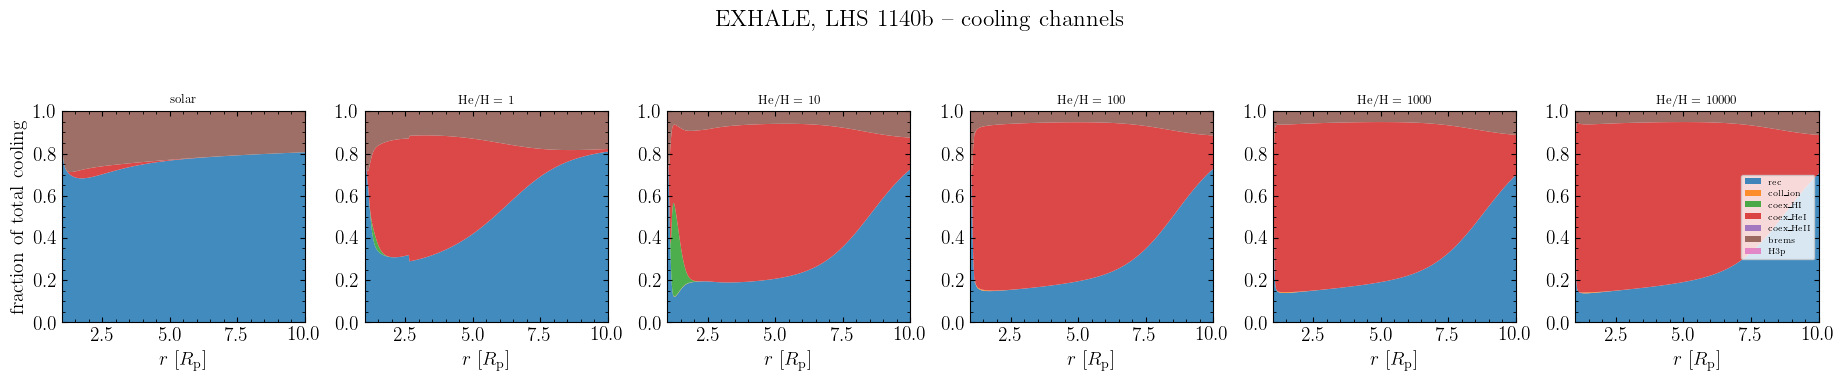

In [15]:
have = [h for h in sorted(ex) if 'cool_bd' in ex[h]]
if have:
    fig, axs = plt.subplots(1, len(have), figsize=(3.1*len(have), 3.6),
                            squeeze=False)
    for k, heh in enumerate(have):
        d = ex[heh]; cb = d['cool_bd']; a = axs[0, k]
        r = cb['r']; tot = np.maximum(cb['cool_total'], 1e-300)
        names = [n for n in eio.COOL_GAS_CHANNELS if n in cb['chan']]
        fr = [np.clip(cb['chan'][n]/tot, 0, 1) for n in names]
        a.stackplot(r, *fr, labels=names, alpha=0.85)
        a.set_xlim(1, 10); a.set_ylim(0, 1)
        a.set_title('solar' if heh < 0.1 else f'He/H = {heh:g}', fontsize=9)
        a.set_xlabel(r'$r$ [$R_{\rm p}$]')
        if k == 0: a.set_ylabel('fraction of total cooling')
    axs[0, -1].legend(fontsize=6, loc='center right')
    fig.suptitle('EXHALE, LHS 1140b -- cooling channels', y=1.06)
    plt.tight_layout()
else:
    print('no converged cases with a cooling breakdown yet')

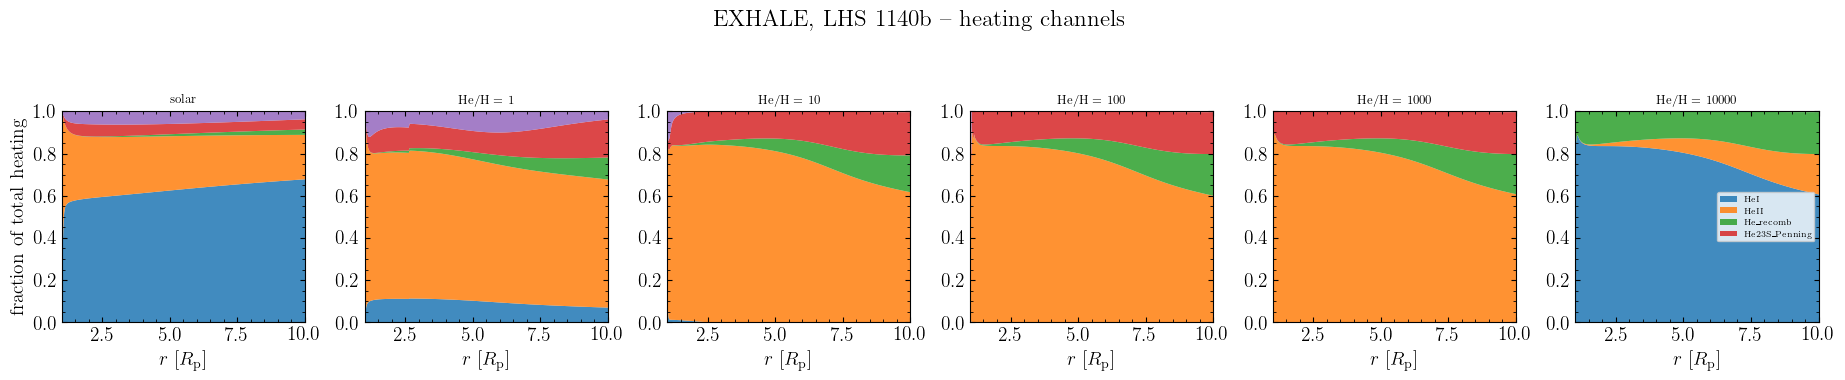

In [16]:
have = [h for h in sorted(ex) if 'heat_bd' in ex[h]]
if have:
    fig, axs = plt.subplots(1, len(have), figsize=(3.1*len(have), 3.6),
                            squeeze=False)
    for k, heh in enumerate(have):
        d = ex[heh]; hb = d['heat_bd']; a = axs[0, k]
        r = hb['r']
        tot = np.maximum(sum(hb['chan'].values()), 1e-300)
        names = [n for n in HEAT_CH if n in hb['chan']
                 and np.max(hb['chan'][n]/tot) > 0.02]
        fr = [np.clip(hb['chan'][n]/tot, 0, 1) for n in names]
        a.stackplot(r, *fr, labels=names, alpha=0.85)
        a.set_xlim(1, 10); a.set_ylim(0, 1)
        a.set_title('solar' if heh < 0.1 else f'He/H = {heh:g}', fontsize=9)
        a.set_xlabel(r'$r$ [$R_{\rm p}$]')
        if k == 0: a.set_ylabel('fraction of total heating')
    axs[0, -1].legend(fontsize=6, loc='center right')
    fig.suptitle('EXHALE, LHS 1140b -- heating channels', y=1.06)
    plt.tight_layout()
else:
    print('no converged cases with a heating breakdown yet')

### 6.3 The He 10830 line, with the measurement under it

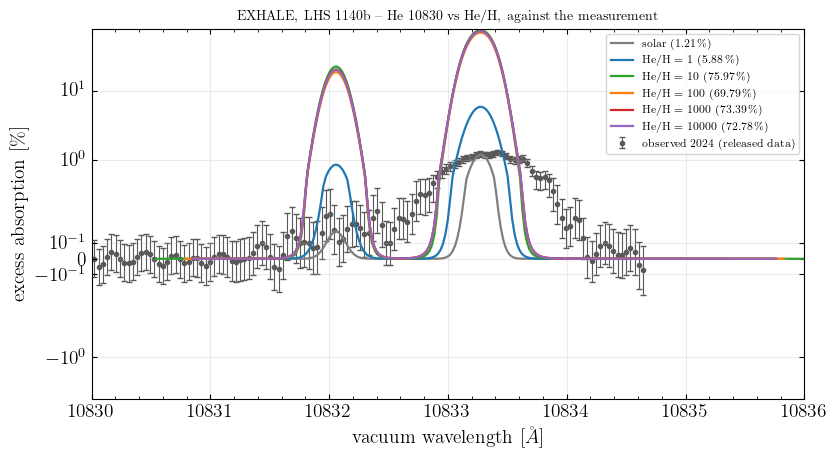

In [17]:
have = [h for h in sorted(ex) if 'spec' in ex[h]]
if have:
    # tpm files are in the AIR frame; the observation is vacuum. Shift by
    # the He triplet's own air-vacuum offset (he_line_metrics constants),
    # constant to <1e-4 A across this 6 A window.
    from he_line_metrics import LAM_VAC, LAM_AIR
    d_air2vac = float(np.mean(LAM_VAC - LAM_AIR))
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    ax.errorbar(obs['lam'], obs['dep'], yerr=obs['sig'], fmt='o', ms=3,
                color='0.35', lw=0.8, capsize=2, zorder=1,
                label='observed 2024 (released data)')
    for heh in have:
        d = ex[heh]
        exc = (d['spec']['t_instr'].max() - d['spec']['t_instr']) \
              / d['spec']['t_instr'].max()*100
        lam_vac = d['spec']['lam'] + d_air2vac
        lab = 'solar' if heh < 0.1 else f'He/H = {heh:g}'
        if 'metrics' in d:
            lab += f"  ({d['metrics']['red_depth']:.2f}" + r'\,\%)'
        ax.plot(lam_vac, exc, color=COLORS[heh], lw=1.6, label=lab)
    ax.set_xlim(10830, 10836)
    ax.ticklabel_format(axis='x', useOffset=False, style='plain')
    ax.set_xlabel(r'vacuum wavelength [$\AA$]')
    ax.set_ylabel(r'excess absorption [\%]')
    ax.set_title('EXHALE, LHS 1140b -- He 10830 vs He/H, against the measurement',
                 fontsize=10)
    ax.set_yscale('symlog', linthresh=0.5)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    plt.tight_layout()
else:
    print('no converged cases with a transit spectrum yet')

The panel above needs a log scale because the helium-dominated cases
absorb 70 %. Below, the same measurement on its own linear scale, with only
the models that land near it: EXHALE at solar composition, EXHALE at
He/H = 1, and p-winds at the paper's H:He $= 10^{-3}$. This is where the
width mismatch is plain: both models that reproduce the *depth* are
narrower than the measured line.

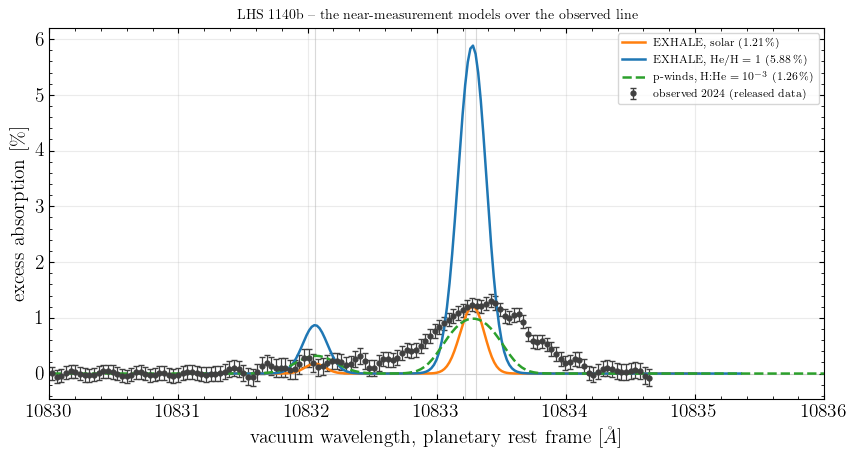

In [18]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.errorbar(obs['lam'], obs['dep'], yerr=obs['sig'], fmt='o', ms=3.5,
            color='0.25', lw=0.9, capsize=2, zorder=2,
            label='observed 2024 (released data)')

# EXHALE solar and He/H = 1
for heh, col in ((0.0833, 'C1'), (1.0, 'C0')):
    d = ex.get(heh)
    if d is None or 'spec' not in d: continue
    exc = (d['spec']['t_instr'].max() - d['spec']['t_instr']) \
          / d['spec']['t_instr'].max()*100
    lab = ('EXHALE, solar' if heh < 0.1 else f'EXHALE, He/H = {heh:g}') \
          + f"  ({d['metrics']['red_depth']:.2f}" + r'\,\%)'
    ax.plot(d['spec']['lam'] + d_air2vac, exc, color=col, lw=1.8, label=lab)

# p-winds at the paper's composition (vacuum frame already)
pw = np.loadtxt('pwinds_oracle/tspec_hhe_0p001.txt')
ax.plot(pw[:, 0], pw[:, 3], color='C2', lw=1.8, ls='--',
        label=r'p-winds, H:He $= 10^{-3}$  (1.26\,\%)')

for lam0 in (10832.057, 10833.217, 10833.306):
    ax.axvline(lam0, color='0.85', lw=0.8, zorder=0)
ax.axhline(0, color='0.85', lw=0.8, zorder=0)
ax.set_xlim(10830, 10836); ax.set_ylim(-0.45, 6.2)
ax.ticklabel_format(axis='x', useOffset=False, style='plain')
ax.set_xlabel(r'vacuum wavelength, planetary rest frame [$\AA$]')
ax.set_ylabel(r'excess absorption [\%]')
ax.set_title('LHS 1140b -- the near-measurement models over the observed line',
             fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()

### 6.3.1 In the paper's own presentation (Fig. 4 style)

The same comparison drawn the way Cherubim et al. (2026) draw their Fig. 4:
normalized flux against **air** wavelength, the 2024 GP-corrected spectrum
in black, model curves over it. Panel A carries our p-winds reproduction at
the two retrieval-point temperatures; panel B carries EXHALE. The paper's
detection-limit convention (0.6 %) is the dashed line.

Per the working priority, the **red** (blended) component is the one to
match; the blue component disagrees between data and every model here and
in the paper's own Fig. 4, and is set aside.

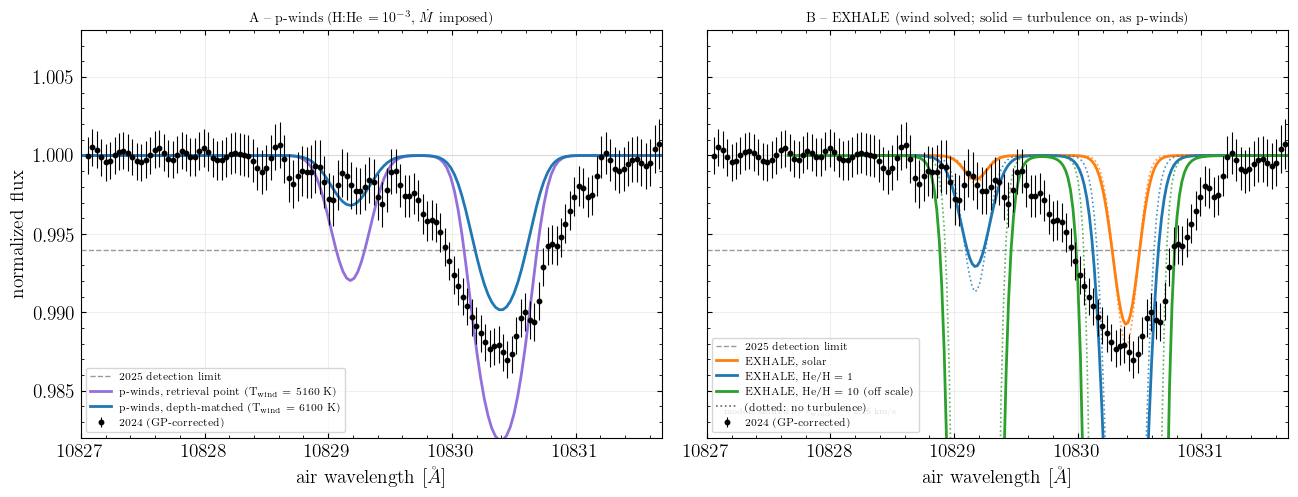

In [19]:
AIR_TO_VAC = 10832.057/10829.09114
# Neither model applies a line-of-sight bulk velocity, so shift both by the
# value C26 fit (v_wind = 2.26 km/s). Equivalent width is unaffected.
DLAM = 2.26/2.99792458e5*10830.0
obs_air  = gcol('wavelength_air_planet_rest_A')
obs_flux = gcol('fig4_normalized_flux')
obs_fsig = gcol('fig4_normalized_flux_uncertainty_1sigma')

fig, axs = plt.subplots(1, 2, figsize=(13.2, 5.2), sharey=True)
for a in axs:
    a.errorbar(obs_air, obs_flux, yerr=obs_fsig, fmt='ko', ms=3.2, lw=0.8,
               capsize=0, zorder=3, label='2024 (GP-corrected)')
    a.axhline(1.0 - 0.006, color='0.6', ls='--', lw=1,
              label='2025 detection limit')
    a.axhline(1.0, color='0.9', lw=0.8, zorder=0)
    a.set_xlim(10827, 10831.7)
    a.set_xlabel(r'air wavelength [$\AA$]')
    a.ticklabel_format(axis='x', useOffset=False, style='plain')
    a.grid(alpha=0.2)
axs[0].set_ylabel('normalized flux')
axs[0].set_ylim(0.982, 1.008)

# ---- A: p-winds, both broadening settings ----
for fn, lab, col in (
        ('pwinds_oracle/tspec_published_gj1132.txt',
         r'retrieval point (T$_{\rm wind}$ = 5160 K)', 'mediumpurple'),
        ('pwinds_oracle/tspec_matched_gj1132.txt',
         r'depth-matched (T$_{\rm wind}$ = 6100 K)', 'C0')):
    t = np.loadtxt(fn)
    lam_air, exc = t[:, 0]/AIR_TO_VAC, t[:, 3]
    axs[0].plot(lam_air + DLAM, 1.0 - exc/100, color=col, lw=2,
                label='p-winds, ' + lab)
axs[0].legend(fontsize=7.5, loc='lower left')
axs[0].set_title(r'A -- p-winds (H:He $= 10^{-3}$, $\dot M$ imposed)',
                 fontsize=10)

# ---- B: EXHALE, turbulence off (dotted) and on (solid) ----
for heh, col, lab in ((0.0833, 'C1', 'solar'),
                      (1.0, 'C0', 'He/H = 1'),
                      (10.0, 'C2', 'He/H = 10 (off scale)')):
    d = ex.get(heh)
    if d is None: continue
    if 'spec' in d:
        e = (d['spec']['t_instr'].max() - d['spec']['t_instr']) \
            / d['spec']['t_instr'].max()*100
        axs[1].plot(d['spec']['lam'] + DLAM, 1.0 - e/100, color=col, lw=1.2,
                    ls=':', alpha=0.8)
    if 'spec_turb' in d:
        e = (d['spec_turb']['t_instr'].max() - d['spec_turb']['t_instr']) \
            / d['spec_turb']['t_instr'].max()*100
        axs[1].plot(d['spec_turb']['lam'] + DLAM, 1.0 - e/100, color=col, lw=2,
                    label='EXHALE, ' + lab)
axs[1].plot([], [], color='0.4', lw=1.2, ls=':', label='(dotted: no turbulence)')
axs[1].text(0.03, 0.06, r'models shifted by $v_{\rm wind}=+2.26$ km/s',
            transform=axs[1].transAxes, fontsize=6, color='0.35')
axs[1].legend(fontsize=7.5, loc='lower left')
axs[1].set_title(r'B -- EXHALE (wind solved; solid = turbulence on, as p-winds)',
                 fontsize=10)
plt.tight_layout()

### 6.4 Why EXHALE and p-winds disagree so strongly

The helium-dominated EXHALE cases absorb 70 % where p-winds absorbs 1.3 %,
yet the **total** metastable column is comparable — at H:He $= 10^{-3}$
EXHALE's vertical $N(2\,^3S)$ inside the stellar chord is about *half* of
p-winds'. What differs is **where the column sits**, and transit depth is
absorbing *area*, not column:

| | p-winds | EXHALE |
|---|---|---|
| 50 % of the $2\,^3S$ column inside | 1.33 $R_p$ | 5.7 $R_p$ |
| 90 % inside | 1.59 $R_p$ | 10.2 $R_p$ |

The star is only 13.6 $R_p$ across, so metastable helium spread to
10 $R_p$ covers most of the disk (a saturated line then gives
$\sim(10/13.6)^2 \approx 55$–75 %), while p-winds' column hugs the planet
and can darken at most a ring of a few $R_p$ — order 1 %.

The distribution difference is the wind structure, which is the one thing
p-winds imposes and EXHALE solves. At $r = 10\,R_p$ (same composition,
same spectrum): p-winds is isothermal 6100 K by construction, EXHALE's
energy balance gives **1400 K** — the XUV that would maintain 6100 K out
there is simply not absorbed there; p-winds flows at 4.3 km/s (the sound
speed of the imposed temperature), EXHALE at **0.53 km/s**; the density is
correspondingly **9 times higher** in EXHALE, and the cold gas keeps
helium neutral and the metastable level populated far out
($n(2\,^3S) = 40$ cm$^{-3}$ against $2\times10^{-4}$).

Neither model matches the measurement on all counts:

- **Depth**: EXHALE crosses the observed 1.25 % just above *solar*
  composition (solar 1.21 %, He/H = 1 gives 5.88 %) — the opposite end of
  the axis from the paper's H:He $\leq 10^{-3}$; every helium-dominated
  EXHALE case overshoots fifty-fold (70–76 %).
- **Width**: the observed FWHM is $0.86$~\AA{} (24 km/s). EXHALE's cold,
  slow wind gives $0.22$–$0.27$~\AA{} at every composition — it cannot make the
  line broad enough, at any He/H. p-winds' imposed 6100 K gets 0.43–0.47.

Read together: the measured line wants gas that is *hot or fast* (for the
width) but *not too extended* (for the depth). EXHALE's self-consistent
energy balance produces neither at this XUV flux, which points at the
energy budget — extra heating (magnetic, stellar-wind interaction) or a
higher EUV flux than the v23 proxy provides — rather than at composition
alone. The paper's composition constraint inherits its isothermal-wind
assumption: impose a 6100 K structure and only helium-rich gas absorbs
enough; solve the energy balance and the inference reverses.

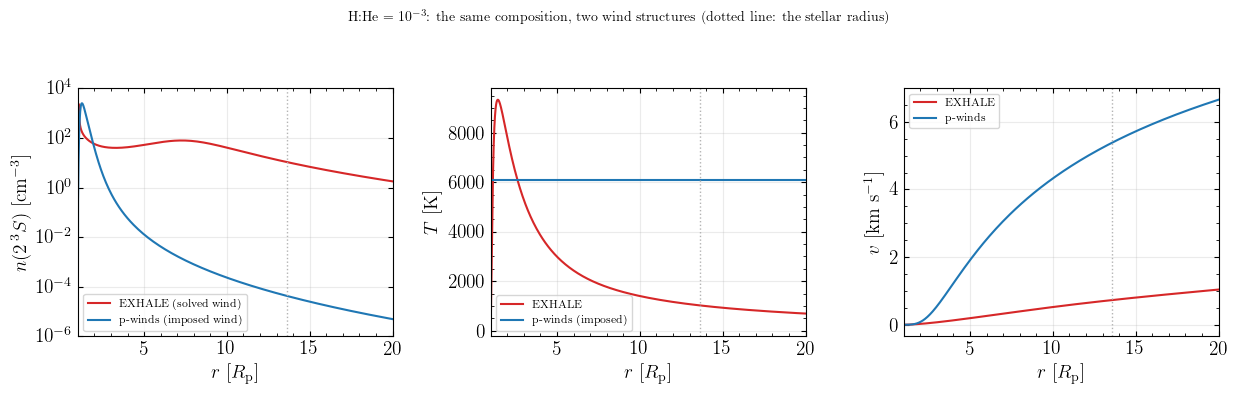

In [20]:
# the structural comparison behind Sect. 6.4, at H:He = 1e-3
pw = np.loadtxt('pwinds_oracle/profile_matched_gj1132.txt')
rp_, vp_, rhop_, fHIIp_, fHe3p_, n3p_ = pw.T
d = ex.get(1000.0)
if d is not None:
    fig, ax = plt.subplots(1, 3, figsize=(12.6, 3.8))
    r = d['r']
    ion = d['ion']
    ax[0].semilogy(r, np.maximum(ion['HeITR'], 1e-8), 'C3',
                   label='EXHALE (solved wind)')
    ax[0].semilogy(rp_, np.maximum(n3p_, 1e-8), 'C0',
                   label='p-winds (imposed wind)')
    ax[0].set_ylabel(r'$n(2\,^3S)$ [cm$^{-3}$]'); ax[0].set_ylim(1e-6, 1e4)
    ax[1].plot(r, d['T'], 'C3', label='EXHALE')
    ax[1].axhline(6100, color='C0', label='p-winds (imposed)')
    ax[1].set_ylabel(r'$T$ [K]')
    ax[2].plot(r, d['v']/1e5, 'C3', label='EXHALE')
    ax[2].plot(rp_, vp_, 'C0', label='p-winds')
    ax[2].set_ylabel(r'$v$ [km s$^{-1}$]')
    for a in ax:
        a.set_xlim(1, 20); a.set_xlabel(r'$r$ [$R_{\rm p}$]')
        a.axvline(13.6, color='0.7', ls=':', lw=1)   # stellar radius
        a.grid(alpha=0.25); a.legend(fontsize=8)
    fig.suptitle(r'H:He $= 10^{-3}$: the same composition, two wind structures'
                 ' (dotted line: the stellar radius)', y=1.04, fontsize=10)
    plt.tight_layout()

### 6.5 What He/H matches the observed line, by equivalent width

Depth and width trade against each other under any broadening, but the
**equivalent width** does not: it is invariant under the instrument LSF, the
turbulence term, and the pipeline kernel of Sect. 5.2. It is therefore the
one quantity on which a self-consistent model can be matched to the
measurement without first settling the broadening question.

Measured over the blended red pair (vacuum $10832.6$–$10834.2$~\AA{}), the
released 2024 spectrum gives $EW = 1.108 \pm 0.030$ %$\cdot$\AA{}. The
EXHALE scan is filled in between solar and He/H $= 1$, each case a JFNK
solution seeded from the He/H $= 1$ wind (`load_IC` rescales the composition),
and the crossing read off directly.

observed red EW = 1.1084 +/- 0.0295 %.A

   He/H       EW   EW turb
 0.0833   0.2789    0.2795
   0.25   0.6448    0.6487
    0.5   1.0402    1.0502
   0.55   1.1089    1.1200
    0.6   1.1834    1.1960
    0.7   1.3112    1.3263
      1   1.5977    1.6190
EXHALE, no turbulence: crossing at He/H = 0.550  (H:He = 1.82, 6.6x solar, He mass fraction 0.69)
EXHALE, turbulence on: crossing at He/H = 0.541  (H:He = 1.85, 6.5x solar, He mass fraction 0.68)


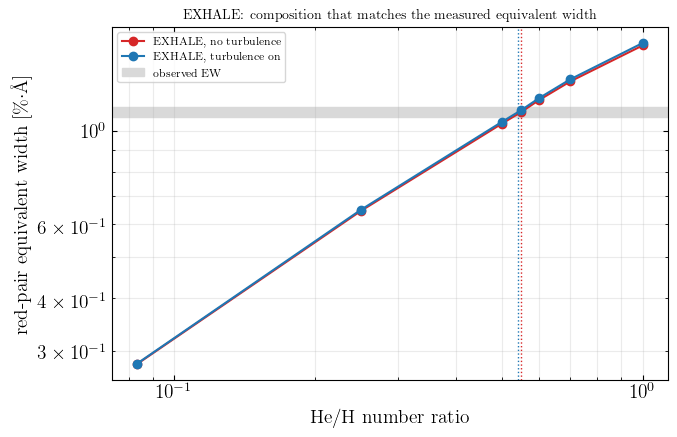

In [21]:
from scipy.optimize import brentq
AIR = 10832.057/10829.09114
EW_LO, EW_HI = 10832.60, 10834.20        # vacuum aperture, blended red pair

def red_ew(tag, sub=''):
    f = os.path.join('archive_20260830', 'exhale', tag, sub, 'tpm_He10830.txt')
    if not os.path.isfile(f):
        return np.nan
    s = np.loadtxt(f)
    lam = s[:, 0]*AIR
    exc = (s[:, 2].max() - s[:, 2])/s[:, 2].max()*100
    m = (lam >= EW_LO) & (lam <= EW_HI)
    return np.trapz(exc[m], lam[m])

m_o = (obs['lam'] >= EW_LO) & (obs['lam'] <= EW_HI)
EW_obs = np.trapz(obs['dep'][m_o], obs['lam'][m_o])
EW_err = np.sqrt(np.sum((obs['sig'][m_o]*np.median(np.diff(obs['lam'])))**2))

SCAN = [('solar', 0.0833), ('heh0p25', 0.25), ('heh0p5', 0.5),
        ('heh0p55', 0.55), ('heh0p6', 0.6), ('heh0p7', 0.7), ('heh1', 1.0)]
hh = np.array([s[1] for s in SCAN])
ew_n = np.array([red_ew(s[0]) for s in SCAN])
ew_t = np.array([red_ew(s[0], 'tpm_turb') for s in SCAN])

print(f'observed red EW = {EW_obs:.4f} +/- {EW_err:.4f} %.A\n')
print(f"{'He/H':>7} {'EW':>8} {'EW turb':>9}")
for a, b, c_ in zip(hh, ew_n, ew_t):
    print(f'{a:7.4g} {b:8.4f} {c_:9.4f}')

fig, ax = plt.subplots(figsize=(7.0, 4.6))
for y, lab, col in ((ew_n, 'EXHALE, no turbulence', 'C3'),
                    (ew_t, 'EXHALE, turbulence on', 'C0')):
    ax.loglog(hh, y, 'o-', color=col, label=lab)
    f = lambda t: np.interp(np.log10(t), np.log10(hh), y)
    x0 = brentq(lambda t: f(t) - EW_obs, hh[0], hh[-1])
    ax.axvline(x0, color=col, ls=':', lw=1)
    print(f'{lab}: crossing at He/H = {x0:.3f}  (H:He = {1/x0:.2f}, '
          f'{x0/0.0833:.1f}x solar, He mass fraction {4*x0/(1+4*x0):.2f})')
ax.axhspan(EW_obs - EW_err, EW_obs + EW_err, color='0.85', zorder=0,
           label='observed EW')
ax.set_xlabel('He/H number ratio')
ax.set_ylabel(r'red-pair equivalent width [\%$\cdot$\AA]')
ax.set_title('EXHALE: composition that matches the measured equivalent width',
             fontsize=10)
ax.grid(alpha=0.25, which='both'); ax.legend(fontsize=8)
plt.tight_layout()

## 7. Depth against composition — EXHALE, p-winds, observed

One axis (H:He, the paper's convention), three sources: the p-winds scan of
Sect. 5, the EXHALE scan of Sect. 6, and the measured blended-red depth of
Sect. 4. This is the figure the composition constraint rests on: where each
model's curve crosses the observed band is that model's H:He.

The two models bracket the measurement from opposite sides, and their
composition inferences are opposite: p-winds (isothermal, $\dot M$ imposed)
reaches the observed depth only when helium dominates; EXHALE (energy
balance solved) is at the observed depth at solar composition and
overshoots fifty-fold when helium dominates. Sect. 6.4 traces this to the
imposed-versus-solved wind structure. The line width (Sect. 6.4) is matched
by neither and argues for missing heating rather than for composition.

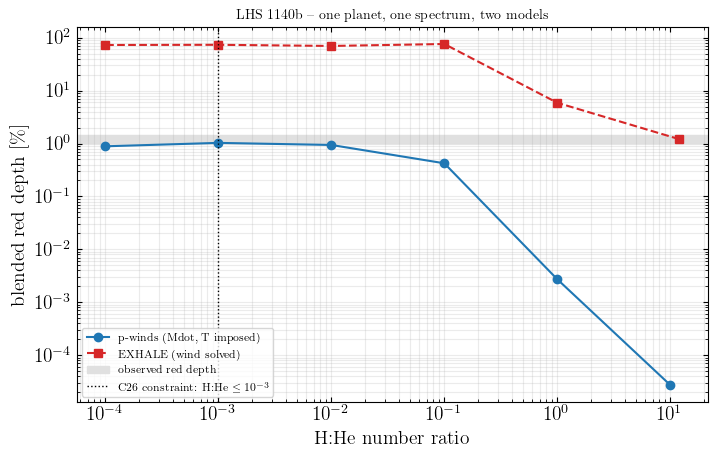

In [22]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
scan = np.loadtxt('pwinds_oracle/scan_hhe.txt')
ax.loglog(scan[:, 0], scan[:, 4], 'o-', color='C0',
          label='p-winds (Mdot, T imposed)')
hs = [h for h in sorted(ex) if 'metrics' in ex[h]]
if hs:
    ax.loglog([1.0/h for h in hs],
              [ex[h]['metrics']['red_depth'] for h in hs],
              's--', color='C3', label='EXHALE (wind solved)')
ax.axhspan(obs_fit['red_depth'] - 0.23, obs_fit['red_depth'] + 0.22,
           color='0.88', zorder=0, label='observed red depth')
ax.axvline(1e-3, color='k', ls=':', lw=1,
           label=r'C26 constraint: H:He $\leq 10^{-3}$')
ax.set_xlabel('H:He number ratio')
ax.set_ylabel(r'blended red depth [\%]')
ax.set_title('LHS 1140b -- one planet, one spectrum, two models', fontsize=10)
ax.grid(alpha=0.25, which='both'); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()

## 8. Status and next steps

| phase | state |
|---|---|
| A1-A4 reference frozen (parameters, SEDs, oracle, metrics) | done |
| B resolved configuration + transit metrics | done, `make check` 5/5 byte-identical |
| C helium-rich audit (tutorial planet) | done as an audit; superseded here by the LHS 1140b scan. Runs remain in `heh_series/` |
| F LHS 1140b science runs | He/H scan running (Sect. 6); observed reference locked to the released spectrum (Sect. 4) |
| D conservative binary H/He diffusion | pending |
| E Photochem adapter + flux-continuity coupling | pending |
| F science runs + collisional validity | pending |

Supporting documents produced along the way:
`../docs/helium_cooling_channels.tex` (why a helium-dominated wind has
almost no line cooling, and what C26 does and does not say about it) and
the CHIANTI refit of the helium coefficients in
`../docs/cooling_formulas.tex` Sect. 3, with the fitting script in
`../cooling_data/fit_helium_cooling.py`.

The oracle's downstream role stays: **EXHALE vs p-winds with identical
inputs** (same SED file, same system parameters, same $(\dot M, T,$
H:He$)$) — `matched_gj1132` is the reference against the observed 2024
line.